In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 84.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


In [ ]:
path = '/content/hurriyet.txt'
with open(path, 'r', encoding='utf-8') as file:
    text = file.read()

In [ ]:
sentences = text.split('\n')
tokens = []
for sentence in sentences:
    words = sentence.strip().split()
    words = [w.lower() for w in words if w]
    if words:
      tokens.append(words)

In [ ]:
print(tokens[:10])

[['iran', 'devlet', 'televizyonu', 'ülkedeki', 'eyaletin', 'sinde', 'yapılan', 'reformcuları', 'protesto', 'amaçlı', 'yürüyüşlere', 'milyonlarca', 'kişinin', 'katıldığını', 'bildirdi'], ['gösterilerde', 'fitnecilere', 'ölüm', 'münafıklara', 'ölüm', 'abd', 'ye', 'ölüm', 'ingiltere', 'ye', 'ölüm', 'sloganları', 'atıldı'], ['dini', 'lider', 'ali', 'hamaney', 've', 'cumhurbaşkanı', 'mahmud', 'ahmedinejad', 'ı', 'destekleyen', 'iranlılar', 'son', 'olaylarda', 'yeğeni', 'öldürülen', 'mir', 'hüseyin', 'musevi', 'başta', 'olmak', 'üzere', 'muhalefet', 'liderlerini', 'kınadılar'], ['musevi', 'ye', 'ölüm', 've', 'idam', 'idam', 'sloganları', 'duyuldu'], ['muhalefet', 'liderleri', 'kaçtı', 'mı', 'aşure', 'günü', 'yaşanan', 'çatışmalarda', 'devlet', 'kaynaklarına', 'göre', 'u', 'terörist', 'olmak', 'üzere', 'kişi', 'ölmüştü'], ['den', 'fazla', 'kişinin', 'yaralandığı', 'olaylar', 'sırasında', 'en', 'az', 'kişi', 'tutuklanmıştı'], ['öte', 'yandan', 'iran', 'haber', 'ajansı', 'irna', 'muhalif', 'lid

In [ ]:
print(len(tokens))

87308


In [ ]:
print(len(sentences))

87381


In [ ]:
%%time
model = Word2Vec(
    tokens,
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,
    workers=4,
    negative=10,
    epochs=10
)

CPU times: user 2min 51s, sys: 129 ms, total: 2min 51s
Wall time: 43.8 s


In [ ]:
model.wv['hollanda']

array([-0.16145928,  0.41704574,  0.14261241, -0.35728562, -0.12164842,
       -0.0179155 ,  0.11320582,  0.11398935, -0.12547071, -0.56465554,
        0.0820438 , -0.5828093 ,  0.28025815, -0.00285718,  0.30489275,
        0.37991697, -0.14360008, -0.6967056 , -0.06559173, -1.2465894 ,
       -0.310334  , -0.07023278,  0.03047512, -0.60928166, -0.09579608,
       -0.69651777, -0.3741656 , -0.21825805, -0.5640405 , -0.36961585,
        0.29846627,  0.10779875,  0.02662483, -1.187378  ,  0.10027663,
        0.33641195, -0.21928853, -0.3826228 , -0.00469796, -0.75580984,
        0.40048528, -0.79180884,  0.20098472,  0.3845885 , -0.01232249,
        0.07546289, -0.10107238, -0.76818174,  0.10019147,  0.23612775,
        0.12643498, -0.2406719 , -0.07063293, -0.18970175, -0.44648528,
       -0.31612292,  0.37914747,  0.30223328, -0.23563442, -0.10751129,
       -0.10717538, -0.29925773, -0.32424513,  0.38882858,  0.07301237,
        0.27493012, -0.3594439 ,  0.02122564, -0.26430032,  0.46

In [ ]:
def most_similar_words(model, word, topn=10):
  key = word.lower()
  if key in model.wv.key_to_index:
    return model.wv.most_similar(key, topn=topn)
  else:
    print(f"Kelime bulunamadı: {key} OOV")
    candidates = [w for w in model.wv.key_to_index.keys() if key in w][:10]
    if candidates:
      print(f"Önerilen Kelimeler: {candidates}")
    return []

In [ ]:
most_similar_words(model, 'hol')

Kelime bulunamadı: hol OOV
Önerilen Kelimeler: ['hollanda', 'hollandalı', 'hollywood', 'stockholm', 'bartholomeos', 'holbrooke', 'holmes', 'nicholas', 'holder', 'holbert']


[]

In [ ]:
def tsne_plot(model, word, topn=10, perplexity=5):
  word = word.lower()
  if word not in model.wv.key_to_index:
    raise KeyError(f"Kelime bulunamadı: {word} OOV")
  words = [word]
  vectors = [model.wv[word]]
  for w, _ in model.wv.most_similar(word, topn=topn):
    words.append(w)
    vectors.append(model.wv[w])

  X = np.array(vectors)
  tsne = TSNE(n_components=2, perplexity=perplexity, random_state=0, init = 'pca', learning_rate='auto')

  Y = tsne.fit_transform(X)
  plt.figure()
  plt.scatter(Y[:, 0], Y[:, 1])

  for label, x, y in zip(words, Y[:, 0], Y[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(5, -2), textcoords='offset points')
    plt.title(f'TSNE Plot of {word}')
  plt.show()

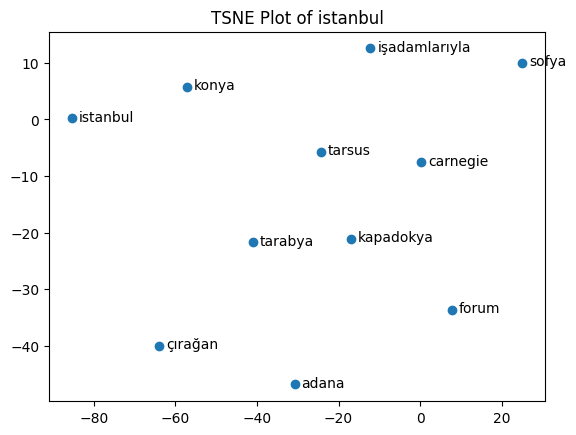

In [ ]:
tsne_plot(model, 'istanbul')